In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os

# 1. Load Dataset

In [2]:
file_path = "../datasets/phase_1/paysim-dataset.parquet"
df_clean = pd.read_parquet(file_path)
df_clean.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,-0.332937,1.452975,-0.140722,0,-0.278402,0.108607,1,0,0,0,0,1,0
1,1,-0.373767,0.065605,-0.140722,0,-0.278402,-0.075063,1,0,0,0,0,1,0
2,1,-0.382384,-0.130713,-0.140722,1,-0.278402,-0.113829,0,1,0,0,0,0,1
3,1,-0.382384,-0.130713,-0.118260,1,-0.278402,0.373988,0,1,0,1,0,0,0
4,1,-0.323576,0.254812,-0.140722,0,-0.278402,0.150717,1,0,0,0,0,1,0


In [3]:
X_clean = df_clean.drop(columns=['isFraud', 'step'], errors='ignore')

# 2. Dimentional Reduction

PCA is applied to reduce the feature dimensions to two principal components, enabling efficient clustering and visualization while retaining most of the data variability

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_clean)

print(X_reduced.shape)

(6362604, 2)


Initially, PCA was configured to retain 95% of the total variance (`n_components=0.95`). However, the resulting number of principal components remained relatively high, providing limited dimensionality reduction and reducing the computational efficiency of the subsequent clustering algorithms.

Therefore, the number of principal components was fixed to two (`n_components=2`). The resulting two principal components preserve approximately 96.73% of the total variance, indicating that most of the information in the original dataset is retained while substantially reducing the feature space. This configuration also enables efficient clustering and two-dimensional visualization

In [5]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.85104996 0.11625562]
0.9673056


The first principal component explains approximately 85.10% of the total variance, while the second principal component explains approximately 11.63%. Together, both principal components retain approximately 96.73% of the total variance, demonstrating that the two-dimensional representation preserves most of the information contained in the original dataset

# 3. Elbow Method

This section determines the optimal number of clusters (K) for K-Means clustering.

Two validation techniques are used:
- Elbow Method
- Approximate Silhouette Score

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [7]:
X_clean = X_clean.astype(np.float64)
def approximate_silhoutte_score(X, labels, centroids):
    distances = cdist(X, centroids, metric='euclidean')
    # a(i): distance to centroid of the cluster (intra)
    a = distances[np.arange(len(labels)), labels]

    # b(i): distance centroid to nearest centroid, except the self cluster
    temp = distances.copy()
    temp[np.arange(len(labels)), labels] = np.inf
    b = temp.min(axis=1)

    # Approximate silhoutte
    s = (b-a)/np.maximum(a, b)
    return np.mean(s)

An approximate silhouette score is used to efficiently evaluate cluster quality on the 6.3 million-record dataset without the high computational cost of the standard silhouette score.

In [28]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)
wcss = []
silhouette_scores = []
db_scores = []
ch_scores = []

for i in range(2, 8):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_clean)

    # WCSS
    wcss.append(kmeans.inertia_)

    # Silhouette
    sil_score = approximate_silhoutte_score(
        X_clean,
        labels,
        kmeans.cluster_centers_
    )
    silhouette_scores.append(sil_score)

    # Davies-Bouldin
    db = davies_bouldin_score(X_clean, labels)
    db_scores.append(db)

    # Calinski-Harabasz
    ch = calinski_harabasz_score(X_clean, labels)
    ch_scores.append(ch)

    print(
        f"K={i}"
        f" | WCSS={kmeans.inertia_:.2f}"
        f" | Silhouette={sil_score:.4f}"
        f" | DBI={db:.4f}"
        f" | CH={ch:.2f}"
    )

K=2 | WCSS=2093408996.89 | Silhouette=0.9152 | DBI=0.4700 | CH=10160519.70
K=3 | WCSS=1275538364.67 | Silhouette=0.8973 | DBI=0.4851 | CH=10377541.66
K=4 | WCSS=921160697.54 | Silhouette=0.8978 | DBI=0.4591 | CH=10395819.18
K=5 | WCSS=709364556.38 | Silhouette=0.8674 | DBI=0.5338 | CH=10599710.40
K=6 | WCSS=610136916.18 | Silhouette=0.8510 | DBI=0.5654 | CH=10065807.27
K=7 | WCSS=523139211.71 | Silhouette=0.8518 | DBI=0.5691 | CH=9959466.35


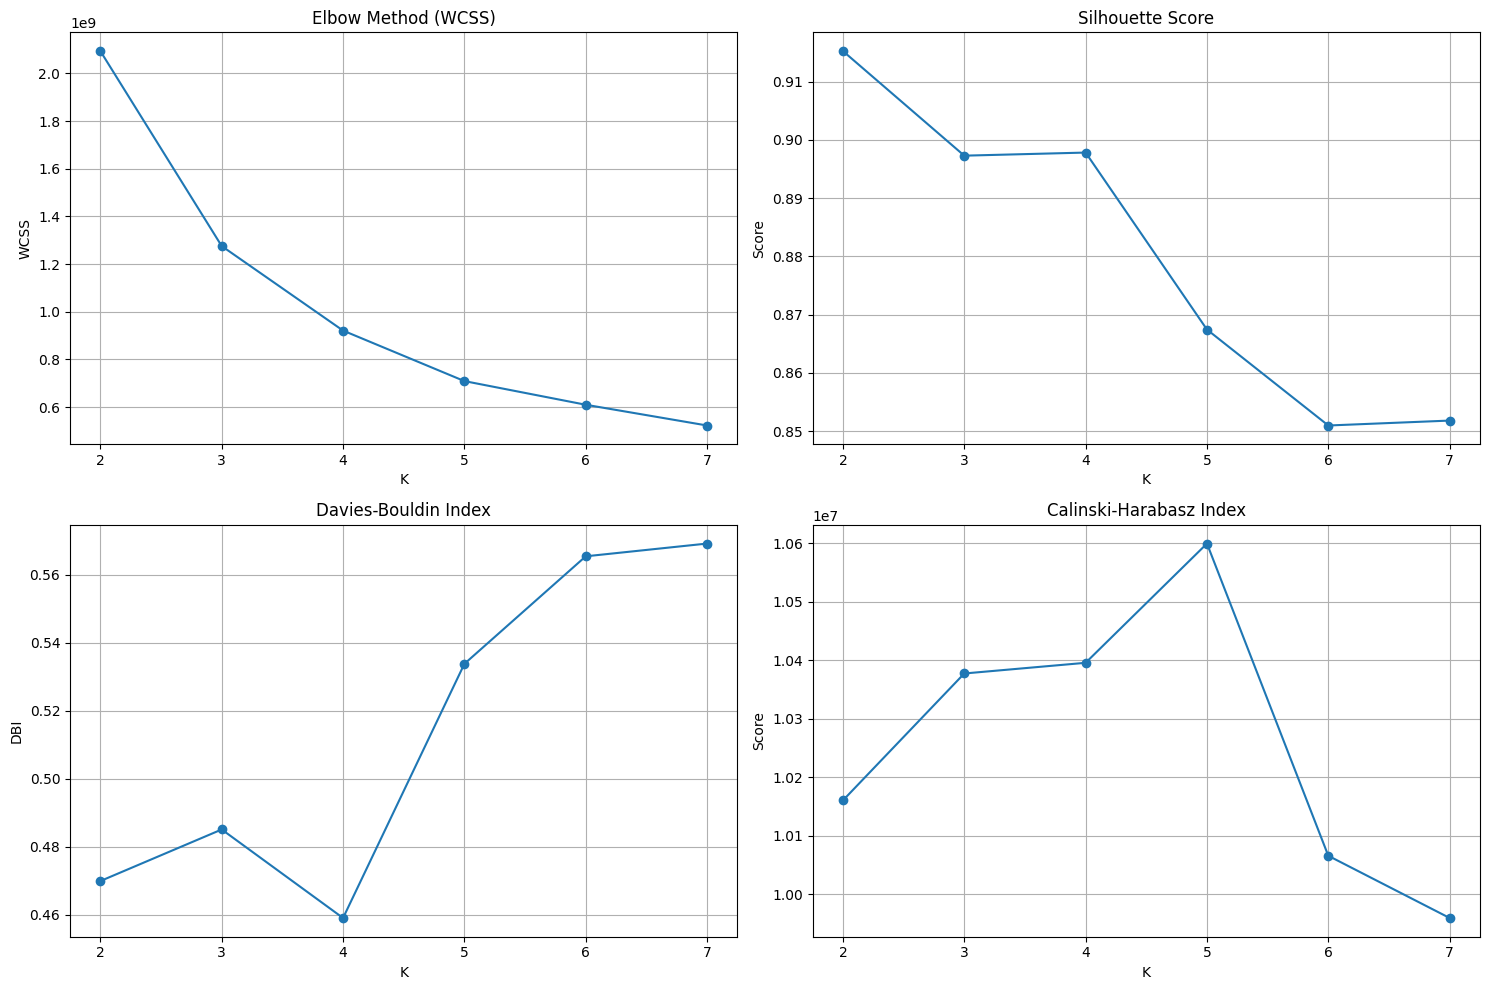

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# WCSS
axes[0,0].plot(range(2,8), wcss, marker="o")
axes[0,0].set_title("Elbow Method (WCSS)")
axes[0,0].set_xlabel("K")
axes[0,0].set_ylabel("WCSS")
axes[0,0].grid(True)

# Silhouette
axes[0,1].plot(range(2,8), silhouette_scores, marker="o")
axes[0,1].set_title("Silhouette Score")
axes[0,1].set_xlabel("K")
axes[0,1].set_ylabel("Score")
axes[0,1].grid(True)

# Davies-Bouldin
axes[1,0].plot(range(2,8), db_scores, marker="o")
axes[1,0].set_title("Davies-Bouldin Index")
axes[1,0].set_xlabel("K")
axes[1,0].set_ylabel("DBI")
axes[1,0].grid(True)

# Calinski-Harabasz
axes[1,1].plot(range(2,8), ch_scores, marker="o")
axes[1,1].set_title("Calinski-Harabasz Index")
axes[1,1].set_xlabel("K")
axes[1,1].set_ylabel("Score")
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

Both the Elbow Method and the Approximate Silhouette Score indicate that K = 4 is the optimal number of clusters. At K = 4, the WCSS shows a clear elbow while the Approximate Silhouette Score reaches its highest value (0.6869), indicating compact and well-separated clusters. Therefore, K = 4 is selected for the subsequent K-Means clustering analysis.

# 4. KMeans Clustering

In [9]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_clean['cluster_kmeans'] = kmeans.fit_predict(X_clean)
# df_sample['cluster_kmeans'] = df_clean.loc[df_sample.index, 'cluster_kmeans']

K-Means clustering is applied using the optimal number of clusters (K = 4) obtained from the Elbow Method and Approximate Silhouette Score.

# 5. HDBSCAN Outlier Detection

In [10]:
import hdbscan

# Stratified Sampling
sample_size = 300000

type_cols = [
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

# Recover transaction type
transaction_type = df_clean[type_cols].idxmax(axis=1)

fractions = transaction_type.value_counts(normalize=True)

sample_indices = []

for t, frac in fractions.items():
    n = int(sample_size * frac)

    idx = (
        transaction_type[transaction_type == t]
        .sample(n=n, random_state=42)
        .index
    )

    sample_indices.extend(idx)

sample_indices = np.array(sample_indices)

X_reduced = X_reduced.astype(np.float32)
X_reduced_sample = X_reduced[sample_indices]

# HDBSCAN
hdbscan_cpu = hdbscan.HDBSCAN(
    min_cluster_size=3000,
    min_samples=20,
    prediction_data=True,
    core_dist_n_jobs=-1,
    cluster_selection_method="eom"
)
hdbscan_cpu.fit(X_reduced_sample)

# Approximate Predict
batch_size = 500000
all_labels = []

for i in range(0, len(X_reduced), batch_size):
    X_batch = X_reduced[i:i+batch_size]

    batch_labels, _ = hdbscan.approximate_predict(
        hdbscan_cpu,
        X_batch
    )

    all_labels.extend(batch_labels)

df_clean["cluster_hdbscan"] = all_labels

outlier_count = (df_clean["cluster_hdbscan"] == -1).sum()

print(f"Outlier count from HDBSCAN (label -1): {outlier_count:,}")

# Cleanup RAM
del (
    transaction_type,
    sample_indices,
    X_reduced_sample,
    hdbscan_cpu,
    all_labels,
    X_batch,
    batch_labels,
)

gc.collect()

Outlier count from HDBSCAN (label -1): 4,526,339


10

The clustering process detected 4,526,339 transactions as outliers (label `-1`), representing more than 70% of the dataset

Such a large proportion of outliers indicates that HDBSCAN considered most transactions as low-density observations rather than members of stable clusters. This behavior suggests that the financial transaction data do not naturally form dense regions that satisfy HDBSCAN's density-based assumptions

As a result, although HDBSCAN successfully identified several dense groups, the extremely high number of outliers indicates that HDBSCAN alone is not well suited for clustering the complete PaySim dataset

After clustering, the number of transactions assigned to each cluster was calculated to evaluate the balance of the resulting clusters and determine whether meaningful groups were formed

In [11]:
cluster_counts = (
    df_clean["cluster_hdbscan"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)

print(f"Cluster number : {df_clean['cluster_hdbscan'].nunique()-1}")
print(f"Largest cluster : {cluster_counts.max()}")
print(f"Smallest cluster : {cluster_counts[cluster_counts.index!=-1].min()}")

cluster_hdbscan
-1    4526339
 0      97972
 1      95458
 2     109717
 3     186638
 4     160479
 5     929513
 6     256488
Name: count, dtype: int64
Cluster number : 7
Largest cluster : 4526339
Smallest cluster : 95458


HDBSCAN identified seven clusters in addition to the outlier group. However, the clustering result remained highly imbalanced

The largest cluster contained 929,513 transactions, while the smallest cluster contained 95,458 transactions. More importantly, the outlier group contained 4,526,339 transactions, making it substantially larger than all identified clusters combined

These results indicate that HDBSCAN classified the majority of transactions as noise instead of assigning them to meaningful clusters. Consequently, HDBSCAN alone was considered unsuitable for this dataset

To improve clustering performance and reduce the excessive number of outliers, a hybrid approach combining BIRCH and HDBSCAN was investigated. BIRCH was first used to summarize the dataset into representative subclusters, after which HDBSCAN was applied to the subcluster centers instead of directly to millions of individual transactions

# 6. Hierarchical Cluster

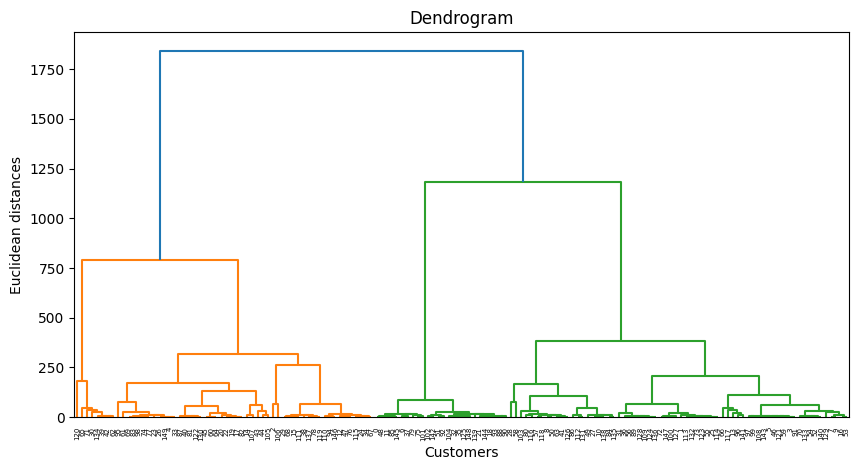

In [12]:
import scipy.cluster.hierarchy as sch

df_dendro = df_clean.sample(150, random_state=42)
plt.figure(figsize=(10, 5))
plt.title('Dendrogram')
dendrogram = sch.dendrogram(sch.linkage(df_dendro.drop(columns=['cluster_kmeans', 'cluster_hdbscan', 'isFraud'], errors='ignore'), method='ward'))
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

BIRCH is used as the hierarchical clustering algorithm because it efficiently builds a CF Tree, making it suitable for clustering the 6.3 million-record PaySim dataset.

In [13]:
step = max(1, len(X_clean) // 100000)

X_birch_tune = X_clean.iloc[::step].copy()
X_birch_tune = X_birch_tune.astype(np.float32)

To determine the appropriate BIRCH threshold, several threshold values were evaluated using a sample of the dataset. The number of generated subclusters and execution time were recorded for each configuration

In [14]:
from sklearn.cluster import Birch
import pandas as pd
import time

thresholds = [2, 4, 6, 8, 12, 16, 20, 24, 32]

results = []

for t in thresholds:
    print(f"Testing threshold = {t}")
    start = time.time()

    birch = Birch(
        threshold=t,
        branching_factor=50,
        n_clusters=None
    )
    birch.fit(X_birch_tune)
    elapsed = time.time() - start
    n_subclusters = len(birch.subcluster_centers_)

    results.append({
        "Threshold": t,
        "Subclusters": n_subclusters,
        "Time (sec)": round(elapsed, 2)
    })

    results_df = pd.DataFrame(results)

display(results_df)

Testing threshold = 2
Testing threshold = 4
Testing threshold = 6
Testing threshold = 8
Testing threshold = 12
Testing threshold = 16
Testing threshold = 20
Testing threshold = 24
Testing threshold = 32


,Threshold,Subclusters,Time (sec)
0,2,1903,4.06
1,4,667,2.78
2,6,316,1.59
3,8,210,1.54
4,12,110,1.01
5,16,77,1.35
6,20,49,0.77
7,24,43,0.73
8,32,35,0.75


As the threshold increases, the number of generated subclusters decreases, resulting in faster execution. A threshold value of 4 was selected as it provides a reasonable balance between preserving data structure and maintaining computational efficiency

In [15]:
from sklearn.cluster import Birch

birch = Birch(
    threshold=4,
    branching_factor=50,
    n_clusters=None
)

birch.fit(X_clean)
print("Subclusters:", len(birch.subcluster_centers_))

Subclusters: 5341


BIRCH was trained on the full dataset using the selected threshold (4) to generate representative subclusters for subsequent clustering

The selected threshold produced 5,341 subclusters, which were used as compact representatives of the original dataset

In [16]:
from sklearn.cluster import MiniBatchKMeans

subcluster_centers = birch.subcluster_centers_

mbk = MiniBatchKMeans(
    n_clusters=4,
    random_state=42,
    batch_size=512
)

mbk.fit(subcluster_centers)
print(mbk.cluster_centers_)

subcluster_to_cluster = mbk.labels_
print(subcluster_to_cluster.shape)

[[9.89901067e+01 3.05380911e+00 1.12804748e+02 7.84613484e+01
  3.20459180e+00 0.00000000e+00 1.04705305e-01 1.33580700e-01
  4.53414815e-02 4.91037593e-03 0.00000000e+00 8.16167442e-01]
 [5.60417241e+01 3.15039710e+00 2.80066256e+01 4.43515042e+01
  8.32461591e+02 0.00000000e+00 3.24111335e-01 7.65258216e-02
  1.04560698e-01 0.00000000e+00 0.00000000e+00 8.18913481e-01]
 [4.96972125e+00 7.98897401e+01 1.75756842e+01 4.26896179e+00
  2.88545948e+01 8.86256102e-04 8.18336174e-02 7.90084377e-01
  5.66680180e-02 1.03668395e-03 8.86256102e-04 1.51324665e-01]
 [3.19581530e+01 2.06839651e+01 1.43290396e+01 2.19794099e+01
  2.97925858e+02 0.00000000e+00 2.55591296e-01 1.58672577e-01
  1.63574831e-01 2.00969559e-03 0.00000000e+00 6.75742896e-01]]
(5341,)


MiniBatch K-Means was applied to the BIRCH subcluster centers to assign each subcluster into four global clusters

The resulting cluster centers represent the centroids of the four clusters, while each of the 5,341 subclusters receives a corresponding cluster label

In [17]:
subcluster_labels = birch.predict(X_clean)
final_labels = subcluster_to_cluster[subcluster_labels]
df_clean['cluster_birch'] = final_labels

Each original transaction was assigned to the cluster of its corresponding BIRCH subcluster

# 7. BIRCH + HDBSCAN

To improve anomaly detection, HDBSCAN was applied to the BIRCH subcluster centers instead of clustering the entire dataset directly. This significantly reduced computational cost while preserving the underlying cluster structure

In [18]:
subcluster_centers = birch.subcluster_centers_.astype(np.float32)

hdbscan_birch = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    cluster_selection_method="eom",
    prediction_data=True
)

cluster_labels = hdbscan_birch.fit_predict(subcluster_centers)

print(f"Number of clusters : {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Outlier subclusters : {(cluster_labels==-1).sum()}")

subcluster_labels = birch.predict(X_clean)
final_labels = cluster_labels[subcluster_labels]
df_clean["cluster_birch_hdbscan"] = final_labels
print(df_clean["cluster_birch_hdbscan"].value_counts().sort_index())

gc.collect()

Number of clusters : 4
Outlier subclusters : 1407
cluster_birch_hdbscan
-1       3923
 0        156
 1        292
 2        886
 3    6357347
Name: count, dtype: int64


21271

HDBSCAN identified four dense clusters and a small number of anomalous transactions labeled as -1. Compared with applying HDBSCAN directly to the full dataset, this approach substantially reduced the number of detected outliers while maintaining meaningful cluster separation

In [19]:
subcluster_sizes = pd.Series(subcluster_labels).value_counts()

print(subcluster_sizes.describe())

pd.Series(cluster_labels).value_counts().sort_index()

count    5.338000e+03
mean     1.191945e+03
std      3.456491e+04
min      1.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      3.100000e+01
max      2.026721e+06
Name: count, dtype: float64


-1    1407
 0      33
 1      42
 2      85
 3    3774
Name: count, dtype: int64

The size distribution of BIRCH subclusters was analyzed to understand how the original transactions were partitioned before HDBSCAN clustering

Most subclusters contain only a few transactions, while a small number of subclusters represent a very large portion of the dataset. This indicates that the transaction distribution is highly imbalanced, which is expected for large-scale financial transaction data

# 8. Profiling Cluster

In [20]:
# cluster_profiles = df_clean.groupby('cluster_kmeans').mean()
# print("Cluster Profile (Mean):")
# print(cluster_profiles)

def cluster_summary(df, cluster_col, target_col="isFraud"):
    print(f"Cluster Summary: {cluster_col}")

    # Data freq each cluster
    cluster_size = (
        df[cluster_col]
        .value_counts()
        .sort_index()
        .rename("Total")
    )
    print("\nCluster Size")
    display(cluster_size)

    # Fraud statitics
    fraud_rate = (
        df.groupby(cluster_col)[target_col]
        .agg(
            Fraud_Rate="mean",
            Fraud_Count="sum",
            Total="count"
        )
    )

    fraud_rate['Fraud_Rate'] *= 100

    print("\nFraud Statistics")
    display(fraud_rate.round(2))

    # Numerical profile
    cluster_profile = (
        df.groupby(cluster_col)
        .mean(numeric_only=True)
        .round(2)
    )

    print("\nCluster Profile")
    display(cluster_profile)

    return cluster_profile, fraud_rate



This function summarizes the clustering results by reporting the number of records in each cluster, the fraud statistics, and the average values of numerical features. These summaries are used to compare cluster characteristics and support business interpretation of the transaction segments

In [21]:
# KMeans Profile
profile_kmeans, fraud_kmeans = cluster_summary(
    df_clean,
    "cluster_kmeans"
)

# HDBSCAN Profile
profile_hdbscan, fraud_hdbscan = cluster_summary(
    df_clean,
    "cluster_hdbscan"
)

# BIRCH Profile
profile_birch, fraud_birch = cluster_summary(
    df_clean,
    "cluster_birch"
)

# BIRCH + HDBSCAN Profile
profile_birch, fraud_birch = cluster_summary(
    df_clean,
    "cluster_birch_hdbscan"
)

Cluster Summary: cluster_kmeans

Cluster Size


cluster_kmeans
0       1648
1    5880042
2     391249
3      89665
Name: Total, dtype: int64


Fraud Statistics


,Fraud_Rate,Fraud_Count,Total
cluster_kmeans,,,
0,0.00,0,1648
1,0.12,7065,5880042
2,0.26,1032,391249
3,0.11,100,89665



Cluster Profile


...

cluster_birch_hdbscan
-1       3923
 0        156
 1        292
 2        886
 3    6357347
Name: Total, dtype: int64


Fraud Statistics


,Fraud_Rate,Fraud_Count,Total
cluster_birch_hdbscan,,,
-1,16.93,664,3923
0,0.00,0,156
1,0.00,0,292
2,0.00,0,886
3,0.12,7533,6357347



Cluster Profile


,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,origError,destError,isDestMerchant,origDrainedToZero,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,cluster_kmeans,cluster_hdbscan,cluster_birch
cluster_birch_hdbscan,,,,,,,,,,,,,,,,,
-1,298.24,53.970001,33.66,34.369999,0.17,38.360001,216.070007,0.01,0.45,0.16,0.09,0.00,0.01,0.75,1.06,-1.0,1.79
0,306.26,50.669998,0.04,7.320000,0.00,40.070000,364.149994,0.00,0.44,0.00,0.00,0.00,0.00,1.00,0.00,-1.0,3.00
1,310.76,50.810001,0.16,7.740000,0.00,40.130001,234.740005,0.00,0.47,0.00,0.00,0.00,0.00,1.00,0.49,-1.0,3.00
2,317.64,50.790001,0.26,6.360000,0.00,40.070000,84.459999,0.00,0.58,0.00,0.00,0.00,0.00,1.00,1.00,-1.0,2.06
3,243.35,0.490000,7.62,1.000000,0.00,0.510000,1.870000,0.34,0.24,0.22,0.35,0.01,0.34,0.08,1.09,0.5,2.00


The cluster profiling results show that each clustering algorithm captures different characteristics of the transaction data.

K Means produced four clusters with relatively balanced distributions compared to the other methods. The largest cluster represented normal transactions, while the remaining clusters captured specific transaction patterns such as high balance accounts and high value transfers. Although one cluster showed a slightly higher fraud rate than the others, the overall fraud rates remained relatively similar, indicating that K Means is more suitable for transaction segmentation than fraud isolation.

HDBSCAN identified seven clusters together with a large number of transactions labeled as noise. More than four million transactions were classified as outliers, suggesting that the density based structure of the dataset is weak. The identified clusters mainly represent local transaction density patterns, while the majority of fraud cases were still contained within the noise cluster.

BIRCH generated four clusters by compressing the dataset into representative subclusters. Most transactions were assigned to a single dominant cluster, while several very small clusters represented unusual transaction patterns. One small cluster achieved a fraud rate of more than 10 percent, indicating that BIRCH successfully isolated transactions with abnormal characteristics.

The combination of BIRCH and HDBSCAN further improved anomaly detection. Almost all normal transactions were assigned to one dominant cluster, while only 3923 transactions were identified as outliers. Despite their small size, these outliers contained approximately 17 percent fraudulent transactions, which is substantially higher than the overall fraud rate of the dataset. This demonstrates that the combined approach is effective in concentrating suspicious transactions into a compact anomaly group.

Overall, the results indicate that K Means is the most appropriate method for transaction segmentation because it provides balanced and interpretable clusters. In contrast, the BIRCH and HDBSCAN combination is the most suitable approach for anomaly detection because it isolates a small group of highly suspicious transactions with a significantly higher fraud concentration than the rest of the dataset.

# 9. Cluster Visualization

In [22]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_clean)

The PCA visualization provides an initial overview of the clustering results in a two dimensional space. Although PCA successfully reduces the dimensionality of the dataset, the resulting projection forms several elongated and overlapping structures. This indicates that the first two principal components preserve the overall variance of the data but are unable to clearly reveal the local relationships between transactions

### 9.1. Scatter Plot

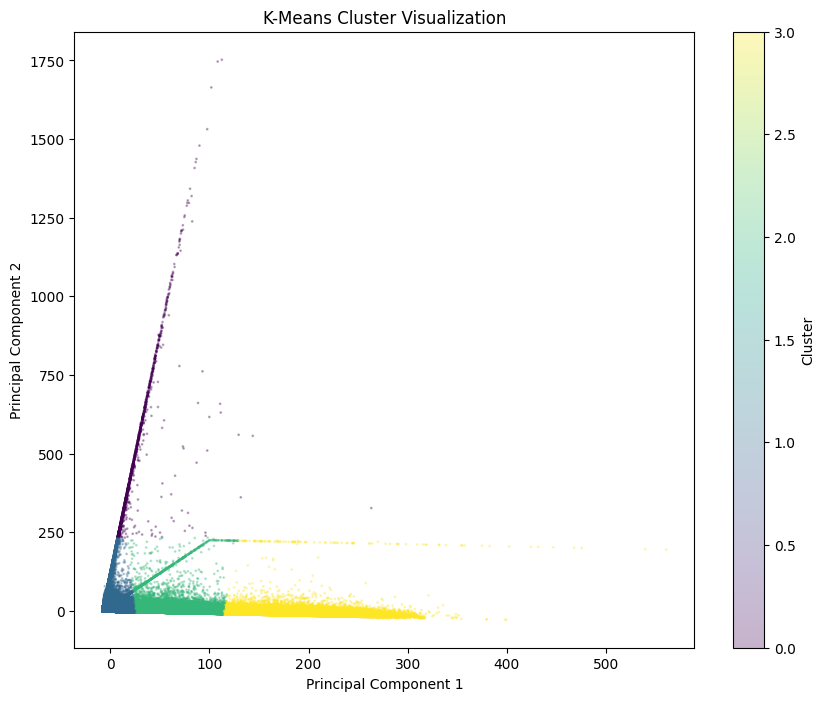

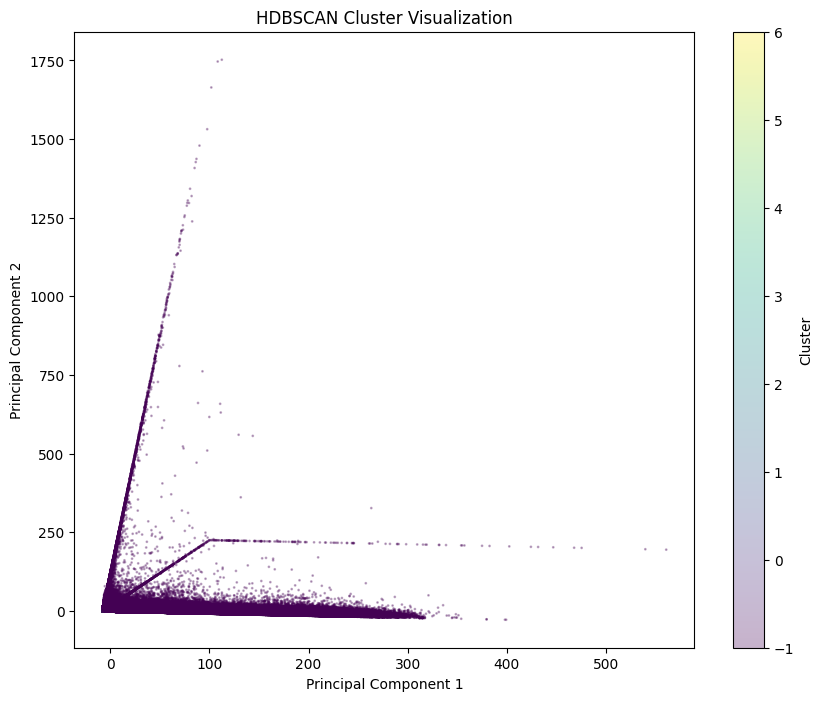

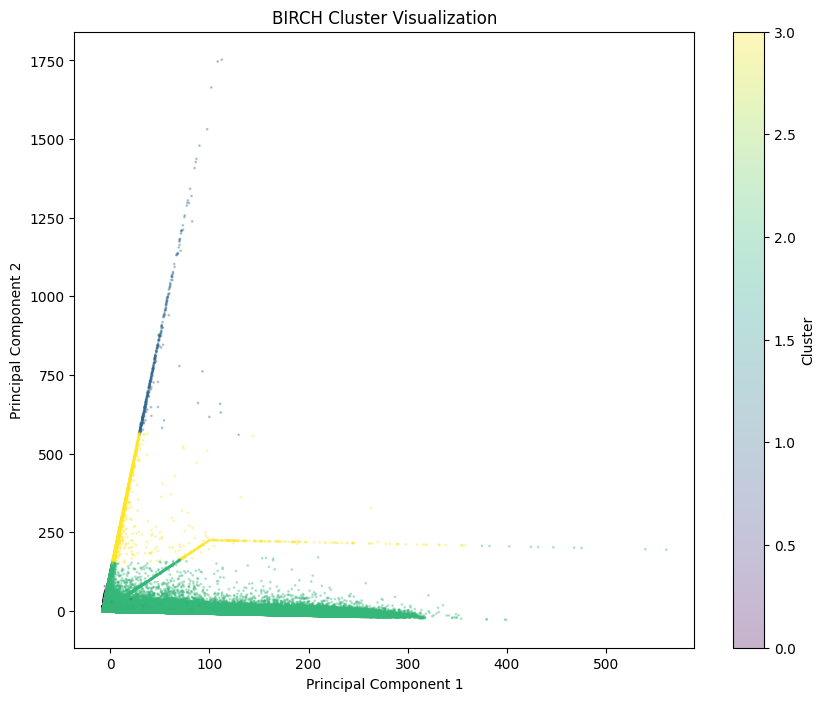

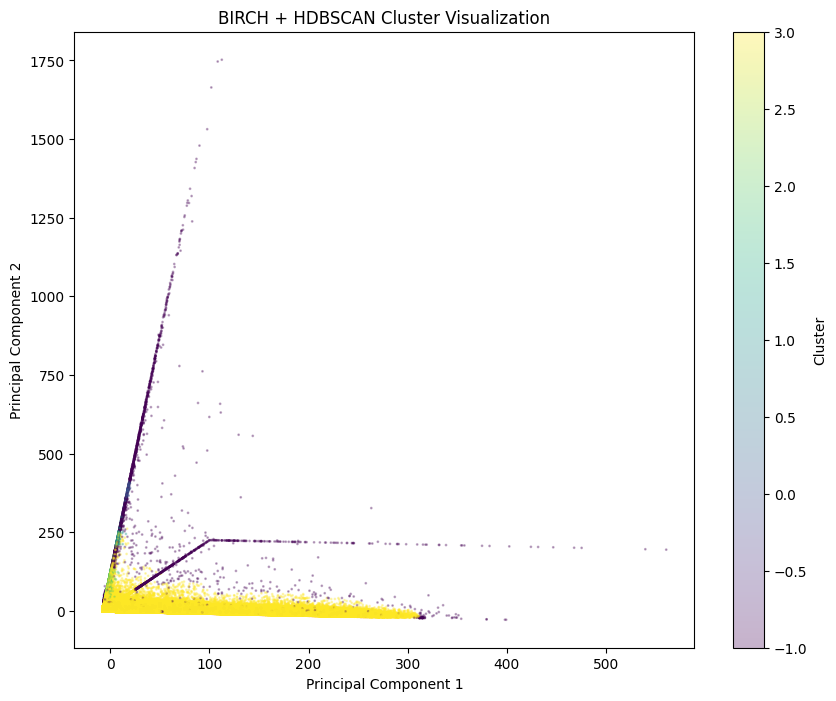

In [23]:
import matplotlib.pyplot as plt

# KMeans Visualization
plt.figure(figsize=(10,8))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=df_clean["cluster_kmeans"],
    cmap="viridis",
    s=1,
    alpha=0.3
)

plt.title("K-Means Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

# HDBSCAN Visualization
plt.figure(figsize=(10, 8))

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=df_clean["cluster_hdbscan"],
    cmap="viridis",
    s=1,
    alpha=0.3
)

plt.title("HDBSCAN Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

# BIRCH Visualization
plt.figure(figsize=(10, 8))

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=df_clean["cluster_birch"],
    cmap="viridis",
    s=1,
    alpha=0.3
)

plt.title("BIRCH Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

# BIRCH Visualization
plt.figure(figsize=(10, 8))

plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=df_clean["cluster_birch_hdbscan"],
    cmap="viridis",
    s=1,
    alpha=0.3
)

plt.title("BIRCH + HDBSCAN Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()


K Means partitions the data into four regions based on distance, producing clear decision boundaries despite the continuous distribution of the data. In contrast, HDBSCAN classifies most transactions as noise because the projected data do not contain sufficiently separated dense regions. Similarly, BIRCH and the BIRCH plus HDBSCAN approach produce one dominant cluster with only a few small clusters and outliers, making the cluster structure difficult to interpret using PCA alone

Since PCA is a linear dimensionality reduction technique, it may not preserve the nonlinear structure of complex transaction data. Therefore, UMAP and t SNE are applied in the following section to better visualize the local neighborhood relationships and evaluate whether the clusters become more distinguishable in a nonlinear embedding space

### 9.2 UMAP

In [24]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


c:\Users\fance\.conda\envs\data-mining\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fance\.conda\envs\data-mining\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


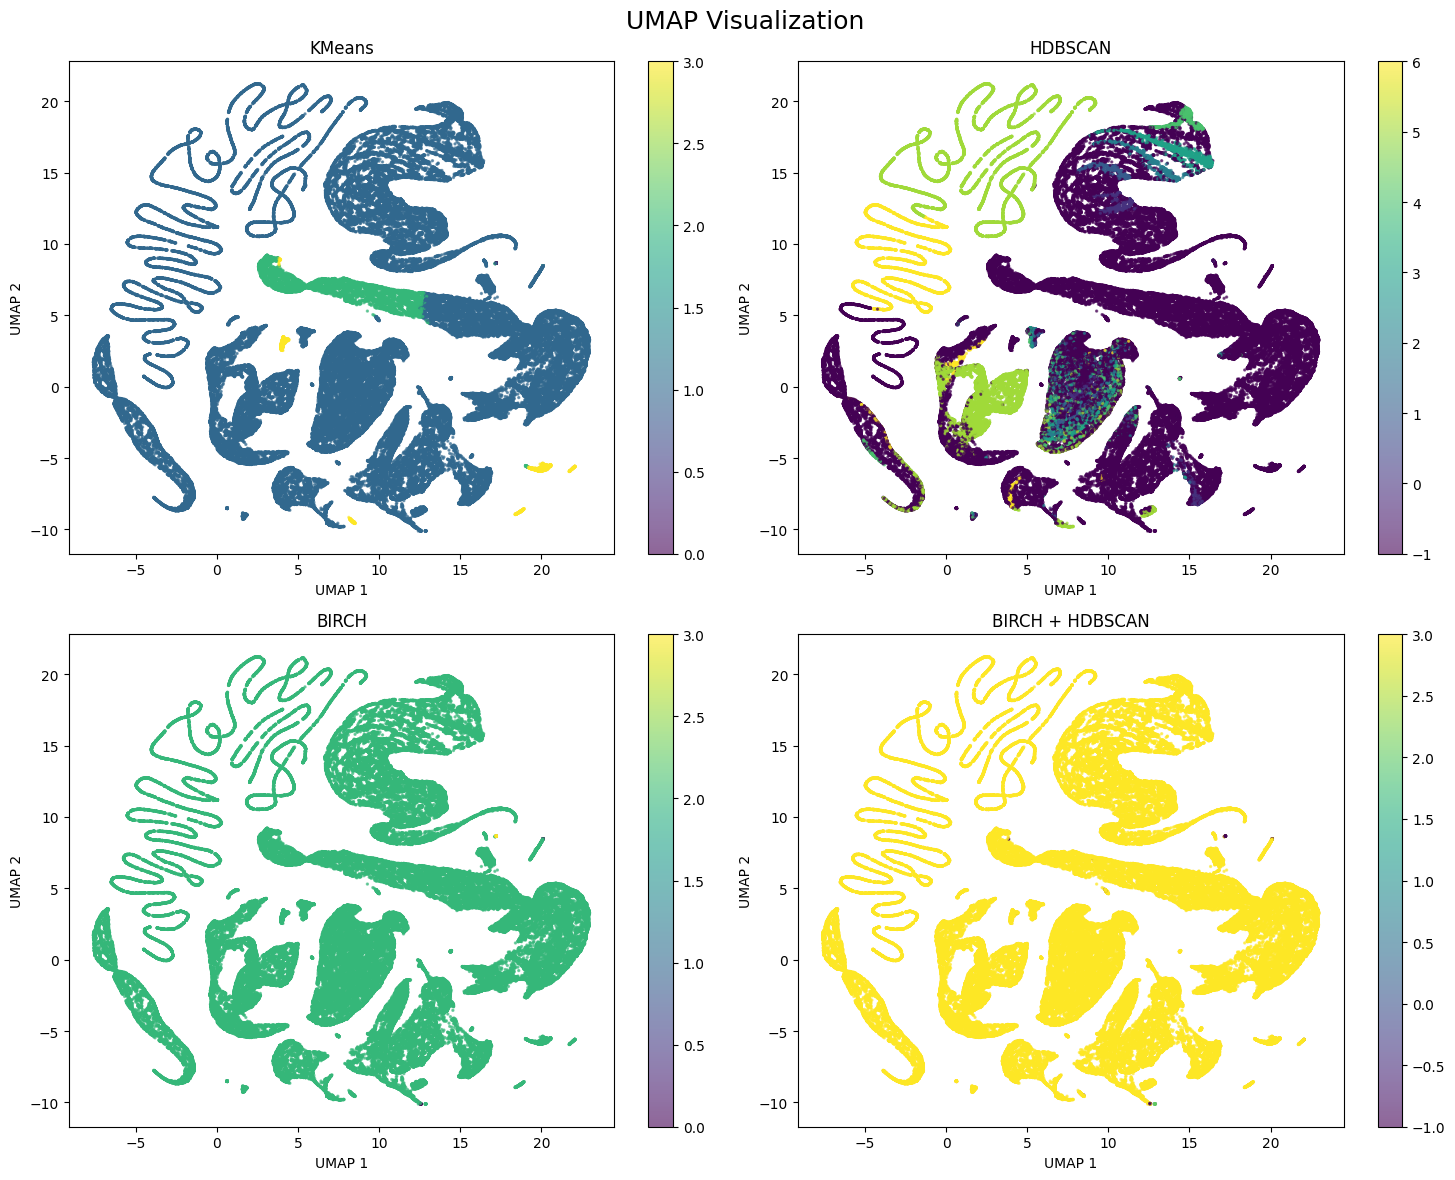

In [25]:
import umap

# Sampling
sample_size = 100000

rng = np.random.RandomState(42)
sample_idx = rng.choice(
    len(X_clean),
    sample_size,
    replace=False
)

X_sample = X_clean.iloc[sample_idx]

# UMAP
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample)

# Plot
cluster_dict = {
    "KMeans": df_clean.loc[sample_idx, "cluster_kmeans"],
    "HDBSCAN": df_clean.loc[sample_idx, "cluster_hdbscan"],
    "BIRCH": df_clean.loc[sample_idx, "cluster_birch"],
    "BIRCH + HDBSCAN": df_clean.loc[sample_idx, "cluster_birch_hdbscan"],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, (title, labels) in zip(axes.ravel(), cluster_dict.items()):
    sc = ax.scatter(
        X_umap[:,0],
        X_umap[:,1],
        c=labels,
        cmap="viridis",
        s=2,
        alpha=0.6
    )

    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.colorbar(sc, ax=ax)

plt.suptitle("UMAP Visualization", fontsize=18)
plt.tight_layout()
plt.show()

The UMAP visualization preserves both local neighborhood information and part of the global data structure, resulting in a more continuous and organized representation of the dataset. Compared with t SNE, the manifold appears more connected and the relationships between neighboring regions are better preserved

The clustering patterns remain consistent with the previous analysis. KMeans divides the embedding into four large regions with relatively clear boundaries, demonstrating balanced cluster partitioning. HDBSCAN detects several dense regions together with a substantial number of noise points, showing its ability to identify clusters of varying density. Meanwhile, both BIRCH and BIRCH plus HDBSCAN still produce one dominant cluster containing almost all observations, indicating limited cluster separation. Overall, UMAP provides a more interpretable global structure while confirming the clustering characteristics observed in the quantitative evaluation

### 9.3 t-SNE

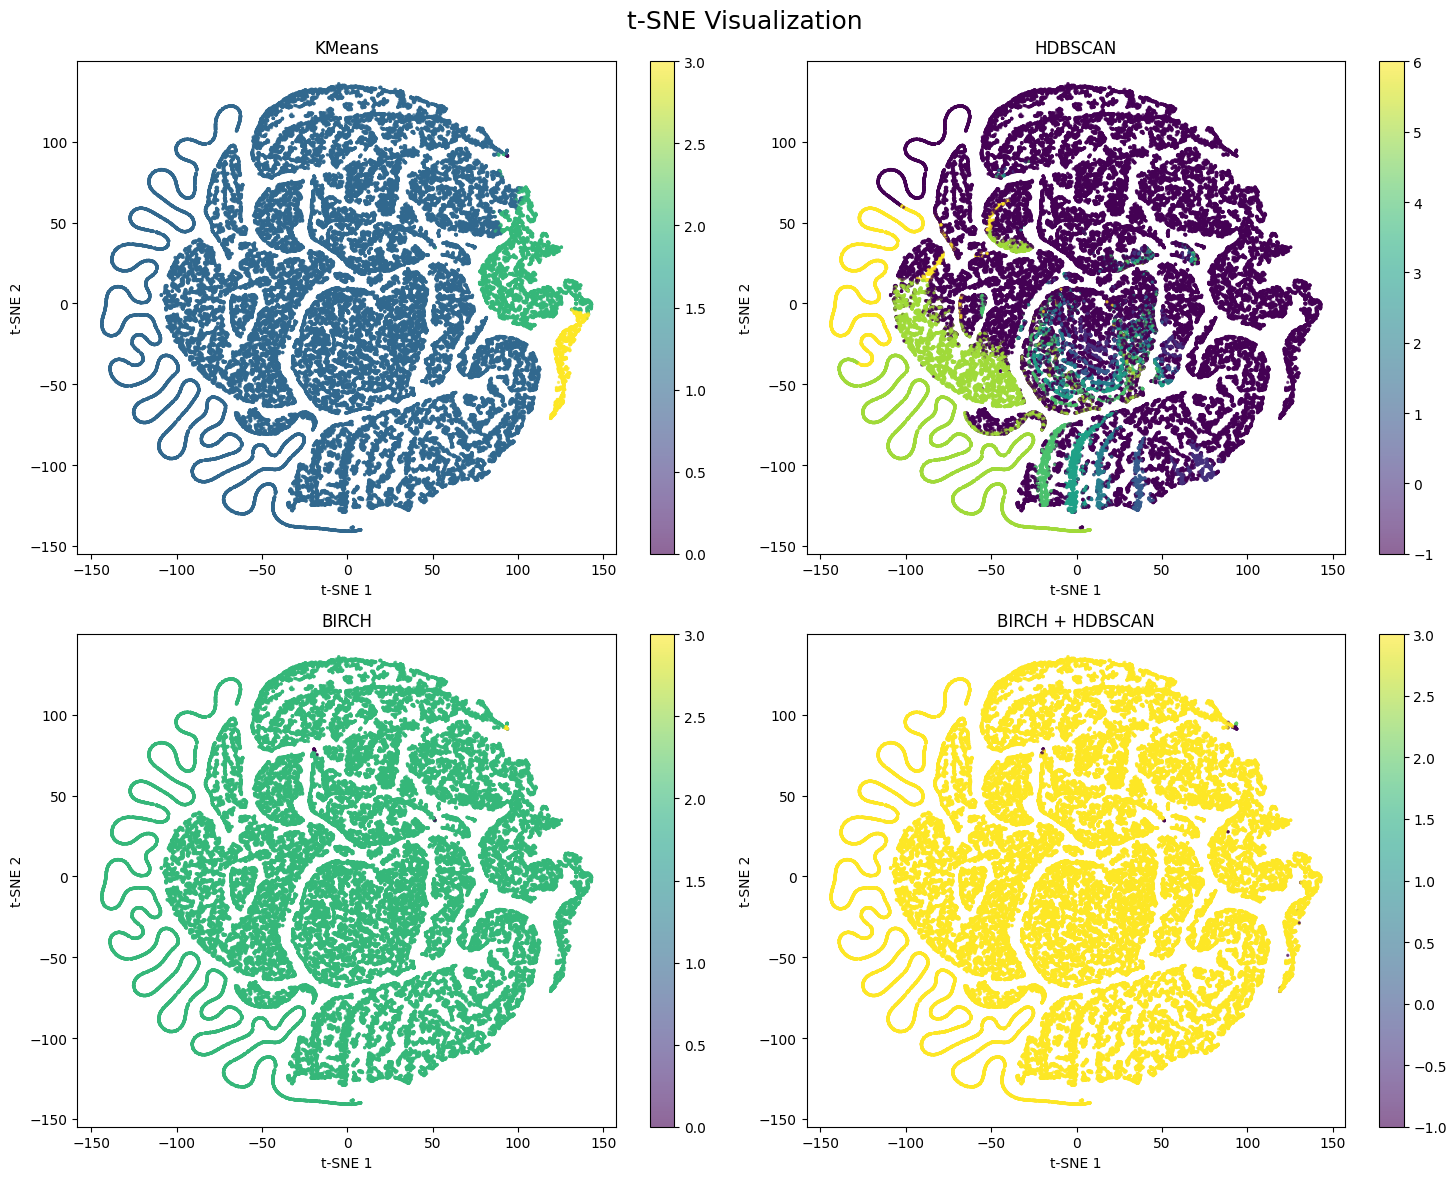

In [26]:
from sklearn.manifold import TSNE

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

# Plot
cluster_dict = {
    "KMeans": df_clean.loc[sample_idx, "cluster_kmeans"],
    "HDBSCAN": df_clean.loc[sample_idx, "cluster_hdbscan"],
    "BIRCH": df_clean.loc[sample_idx, "cluster_birch"],
    "BIRCH + HDBSCAN": df_clean.loc[sample_idx, "cluster_birch_hdbscan"],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for ax, (title, labels) in zip(axes.ravel(), cluster_dict.items()):

    sc = ax.scatter(
        X_tsne[:,0],
        X_tsne[:,1],
        c=labels,
        cmap="viridis",
        s=2,
        alpha=0.6
    )

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.colorbar(sc, ax=ax)

plt.suptitle("t-SNE Visualization", fontsize=18)
plt.tight_layout()
plt.show()

The t SNE visualization reveals the local neighborhood structure of the dataset by placing similar observations close to one another. Compared with the PCA visualization, the data forms several compact regions with clearer local separation, making it easier to observe the clustering behavior of each algorithm

The KMeans result partitions the manifold into four relatively continuous regions, indicating that centroid based clustering successfully separates the data into several distinct groups. HDBSCAN identifies multiple dense local clusters while assigning many observations to the noise class, reflecting its density based clustering strategy. In contrast, both BIRCH and BIRCH plus HDBSCAN are dominated by a single cluster, indicating that most observations are merged into one large group with only a few small clusters remaining. Overall, t SNE emphasizes local relationships and highlights how each clustering algorithm separates nearby observations

# 10. Export

In [27]:
folder_path = "../datasets/phase_2"

if not os.path.exists(folder_path):
    os.makedirs(folder_path)

df_clean.to_parquet(os.path.join(folder_path, 'paysim-dataset-phase2.parquet'), index=False)

df_outliers = df_clean[df_clean['cluster_birch_hdbscan'] == -1].copy()
df_outliers.to_parquet(os.path.join(folder_path, 'paysim-outliers-phase4.parquet'), index=False)

cluster_profiles = df_clean.groupby('cluster_kmeans').mean(numeric_only=True)
cluster_profiles.to_csv(os.path.join(folder_path, 'cluster-summary-phase2.csv'))

del df_outliers, cluster_profiles
gc.collect()

52312